TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

Valor máximo por fila (maxfil): 0.4296875
Número de filas >= 0.90*maxfil: 7
Posiciones de dichas filas: [  6  12  15  20  21  88 100]


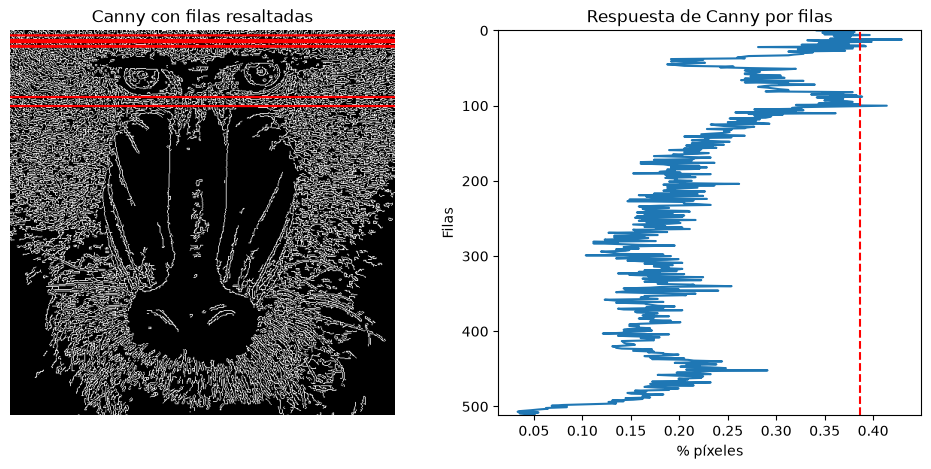

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Lee imagen de archivo, convierte a grises y obtiene contornos con Canny
img = cv2.imread('mandril.jpg')
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 100, 200)

#Cuenta el número de píxeles blancos (255) por fila
#Suma los valores de los pixeles por fila
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de columnas, segundo valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el porcentaje de píxeles blancos por fila
filas = row_counts[:, 0] / (255 * canny.shape[1])

#Valor máximo de píxeles blancos por fila
maxfil = np.max(filas)

#Filas con un número de píxeles blancos mayor o igual que 0.90*maxfil
filas_sel = np.where(filas >= 0.90 * maxfil)[0]

print(f"Valor máximo por fila (maxfil): {maxfil}")
print(f"Número de filas >= 0.90*maxfil: {len(filas_sel)}")
print(f"Posiciones de dichas filas: {filas_sel}")

#Convierte la imagen de Canny a RGB para poder dibujar en color
canny_rgb = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)

#Resalta con una línea roja cada fila que cumple la condición
for fila in filas_sel:
    cv2.line(canny_rgb, (0, int(fila)), (canny.shape[1] - 1, int(fila)), (255, 0, 0), 2)

#Muestra el resultado y la cuenta por filas
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny con filas resaltadas")
plt.imshow(canny_rgb)

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny por filas")
plt.xlabel("% píxeles")
plt.ylabel("Filas")
plt.plot(filas, range(len(filas)))
#Línea vertical en el valor 0.90*maxfil
plt.axvline(0.90 * maxfil, color='r', linestyle='--')
#Rango en y definido por las filas, invertido para coincidir con la imagen
plt.ylim([canny.shape[0], 0])
plt.show()

TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

Sobel - maxfil: 0.314453125, 7 filas: [ 3  4 20 51 81 82 83]
Sobel - maxcol: 0.349609375, 1 columnas: [288]
Canny - maxfil: 0.4296875, 7 filas: [  6  12  15  20  21  88 100]
Canny - maxcol: 0.365234375, 19 columnas: [ 67  86  92  96  99 100 103 104 105 112 115 119 123 379 380 383 392 396
 403]


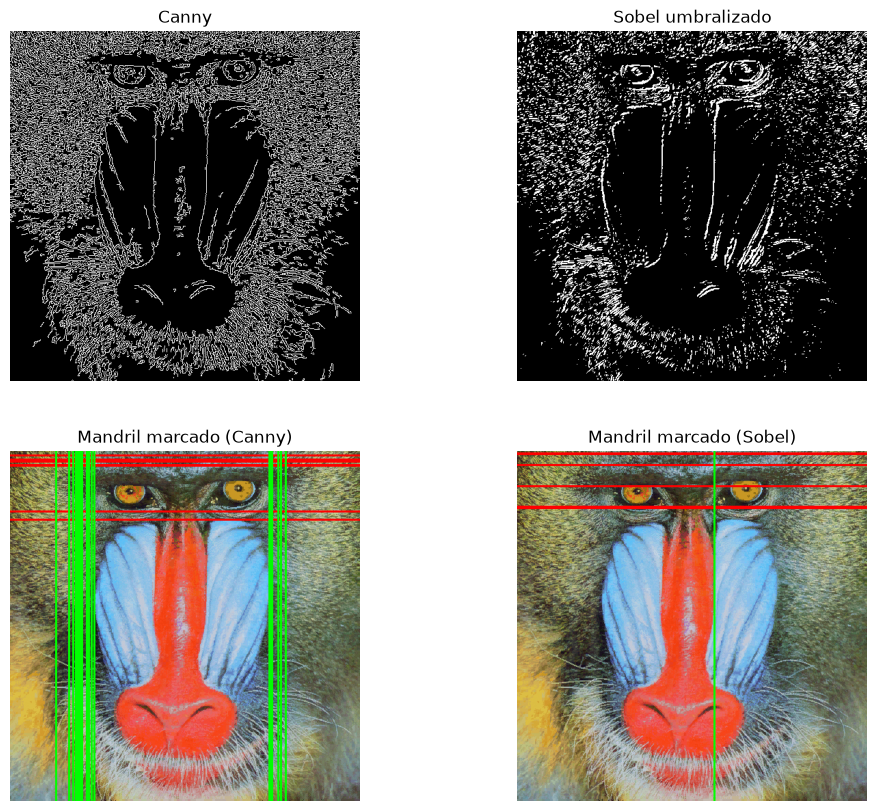

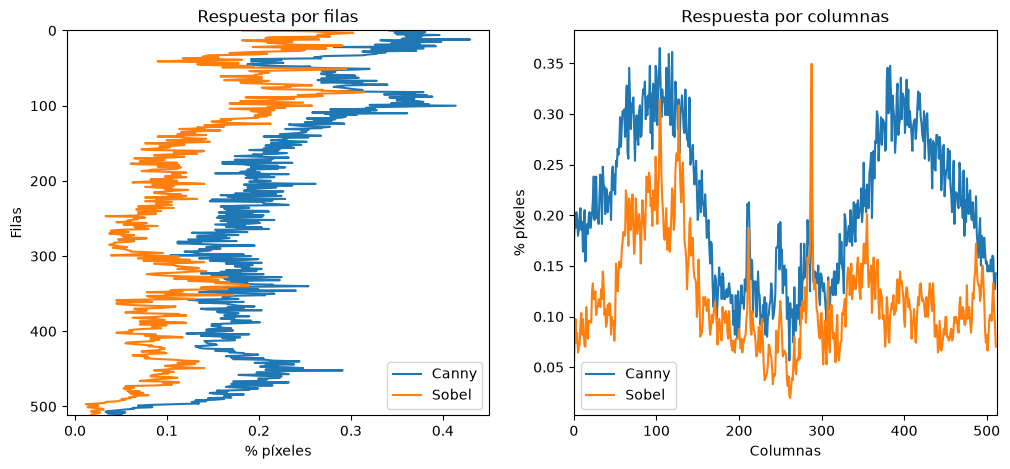

In [18]:
#Convierte el resultado de Sobel a 8 bits
sobel8 = cv2.convertScaleAbs(sobel)

#Define valor umbral y umbraliza la imagen de Sobel
valorUmbral = 130 #Prueba otros valores
_, sobelUmbralizada = cv2.threshold(sobel8, valorUmbral, 255, cv2.THRESH_BINARY)

#Cuenta el número de píxeles blancos (255) por filas y por columnas en Sobel
row_counts_s = cv2.reduce(sobelUmbralizada, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
col_counts_s = cv2.reduce(sobelUmbralizada, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
#Normaliza en base al número de columnas/filas y al valor máximo del píxel (255)
filas_s = row_counts_s[:, 0] / (255 * sobelUmbralizada.shape[1])
cols_s = col_counts_s[0] / (255 * sobelUmbralizada.shape[0])

#Repite la cuenta para Canny
row_counts_c = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
col_counts_c = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
filas_c = row_counts_c[:, 0] / (255 * canny.shape[1])
cols_c = col_counts_c[0] / (255 * canny.shape[0])

#Valores máximos por filas y columnas
maxfil_s = np.max(filas_s)
maxcol_s = np.max(cols_s)
maxfil_c = np.max(filas_c)
maxcol_c = np.max(cols_c)

#Filas y columnas por encima del 0.90*máximo
filas_sel_s = np.where(filas_s >= 0.90 * maxfil_s)[0]
cols_sel_s = np.where(cols_s >= 0.90 * maxcol_s)[0]
filas_sel_c = np.where(filas_c >= 0.90 * maxfil_c)[0]
cols_sel_c = np.where(cols_c >= 0.90 * maxcol_c)[0]

print(f"Sobel - maxfil: {maxfil_s}, {len(filas_sel_s)} filas: {filas_sel_s}")
print(f"Sobel - maxcol: {maxcol_s}, {len(cols_sel_s)} columnas: {cols_sel_s}")
print(f"Canny - maxfil: {maxfil_c}, {len(filas_sel_c)} filas: {filas_sel_c}")
print(f"Canny - maxcol: {maxcol_c}, {len(cols_sel_c)} columnas: {cols_sel_c}")

#Copias de la imagen original en RGB para marcar filas (rojo) y columnas (verde)
mandril_s = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mandril_c = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
alto = gris.shape[0]
ancho = gris.shape[1]

for fila in filas_sel_s:
    cv2.line(mandril_s, (0, int(fila)), (ancho - 1, int(fila)), (255, 0, 0), 2)
for col in cols_sel_s:
    cv2.line(mandril_s, (int(col), 0), (int(col), alto - 1), (0, 255, 0), 2)
for fila in filas_sel_c:
    cv2.line(mandril_c, (0, int(fila)), (ancho - 1, int(fila)), (255, 0, 0), 2)
for col in cols_sel_c:
    cv2.line(mandril_c, (int(col), 0), (int(col), alto - 1), (0, 255, 0), 2)

#Muestra imágenes de bordes y mandril marcado
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray')

plt.subplot(2, 2, 2)
plt.axis("off")
plt.title("Sobel umbralizado")
plt.imshow(sobelUmbralizada, cmap='gray')

plt.subplot(2, 2, 3)
plt.axis("off")
plt.title("Mandril marcado (Canny)")
plt.imshow(mandril_c)

plt.subplot(2, 2, 4)
plt.axis("off")
plt.title("Mandril marcado (Sobel)")
plt.imshow(mandril_s)
plt.show()

#Muestra la respuesta por filas y columnas de ambos detectores
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Respuesta por filas")
plt.xlabel("% píxeles")
plt.ylabel("Filas")
plt.plot(filas_c, range(len(filas_c)), label="Canny")
plt.plot(filas_s, range(len(filas_s)), label="Sobel")
#Rango en y definido por las filas, invertido para coincidir con la imagen
plt.ylim([alto, 0])
plt.legend()

plt.subplot(1, 2, 2)
plt.title("Respuesta por columnas")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(cols_c, label="Canny")
plt.plot(cols_s, label="Sobel")
#Rango en x definido por las columnas
plt.xlim([0, ancho])
plt.legend()
plt.show()

Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

Lo primero que se ve es que Canny da bordes mucho más finos y continuos, de un píxel de grosor, mientras que en Sobel umbralizado los bordes salen más gruesos y cortados. Esto tiene sentido porque Canny adelgaza los bordes y usa dos umbrales para conectarlos, y Sobel con un umbral simple solo se queda con los píxeles que lo superan. También creo que con `cv2.add(sobelx, sobely)` se pierden algunos bordes, porque los valores positivos y negativos se pueden anular. En los dos casos la nariz y las mejillas casi no tienen bordes, y Canny detecta en general más píxeles (máximo por filas del 43 % frente al 31 % de Sobel).

Por filas, los dos dan resultados parecidos. En ambos salen 7 filas, todas en la parte de arriba: en Canny en la frente (6–21) y debajo de los ojos (88 y 100), y en Sobel en la frente (3, 4 y 20), en los ojos (51) y justo debajo (81–83). Es la zona con más pelo y con bordes horizontales como los párpados.

Por columnas sí hay bastante diferencia. En Canny la curva tiene dos zonas altas a los lados de la cara y baja en el centro por la nariz, y las 19 columnas están en 67–123 y 379–403. En Sobel solo sale la columna 288, por un pico muy estrecho al lado de la nariz. El segundo pico (sobre la columna 100) se queda justo por debajo del 0.90*máximo, así que el resultado depende mucho de un solo borde.

En resumen, Canny me parece mejor para este caso porque los bordes son más limpios y las filas y columnas marcadas tienen más sentido con la forma de la cara. Sobel es más sencillo, pero depende mucho del umbral. Aun así, los dos dependen de los parámetros: al probar Canny con 20 y 50 casi toda la imagen salía como borde y la cuenta ya no servía para nada.

TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [21]:
#Privacy Pixelator - reinterpretación de "My little piece of privacy"
#Todo lo que se mueve delante de la webcam se pixela

import cv2
import numpy as np

vid = cv2.VideoCapture(0)
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

#Guarda a la vez el resultado como mp4
out = cv2.VideoWriter('privacy_pixelator.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 20.0, (w, h))

#Kernels para las operaciones morfológicas
k_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (31, 31))

prev_gray = None                      #Fotograma anterior para la diferencia
trail = np.zeros((h, w), np.uint8)    #Memoria del movimiento, para que la zona no parpadee
PIXEL_SIZE = 20                       #Cuanto mayor, más grandes los píxeles

while True:
    ret, frame = vid.read()
    if not ret:
        break
    frame = cv2.flip(frame, 1)        #Efecto espejo

    #Diferencia de fotogramas sobre la imagen en grises suavizada
    gray = cv2.GaussianBlur(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY), (7, 7), 0)
    if prev_gray is None:             #El primer fotograma no tiene con qué compararse
        prev_gray = gray
        continue
    diff = cv2.absdiff(gray, prev_gray)
    prev_gray = gray
    _, motion = cv2.threshold(diff, 15, 255, cv2.THRESH_BINARY)

    #Limpia la máscara: OPEN elimina ruido, CLOSE rellena huecos
    motion = cv2.morphologyEx(motion, cv2.MORPH_OPEN, k_open)
    motion = cv2.morphologyEx(motion, cv2.MORPH_CLOSE, k_close)

    #El movimiento anterior se desvanece poco a poco y se suma el nuevo
    trail = cv2.addWeighted(trail, 0.9, motion, 0.5, 0)
    _, private_mask = cv2.threshold(trail, 40, 255, cv2.THRESH_BINARY)
    private_mask = cv2.dilate(private_mask, k_close)

    #Pixelado: reduce la imagen y la vuelve a ampliar sin suavizar
    small = cv2.resize(frame, (w // PIXEL_SIZE, h // PIXEL_SIZE))
    pixelated = cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)

    #Combina con np.where (sin bucles): pixelado donde la máscara es blanca
    mask_3d = cv2.cvtColor(private_mask, cv2.COLOR_GRAY2BGR)
    result = np.where(mask_3d == 255, pixelated, frame)

    out.write(result)
    cv2.imshow('Privacy Pixelator', result)

    #Detenemos pulsando ESC
    if cv2.waitKey(20) == 27:
        break

#Libera el objeto de captura y el de escritura
vid.release()
out.release()
#Destruye ventanas
cv2.destroyAllWindows()